Fashion MNIST NeuralNet Example using pytorch

In [3]:
import torch
import pandas as pd
from torch import nn
from torch.utils.data import DataLoader
%pip install torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'datasets',
    train= True,
    download = True,
    transform = ToTensor(),
)


# Download test data from open datasets

test_data = datasets.FashionMNIST(
    root="datasets",
    train=False,
    download = True,
    transform = ToTensor(),
)

100%|██████████| 26.4M/26.4M [01:33<00:00, 283kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 99.4kB/s]
100%|██████████| 4.42M/4.42M [00:19<00:00, 226kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.12MB/s]


In [5]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [6]:
batch_size = 64

# Create data loaders

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
  print("Shape of X [N, C, H, W] ", X.shape)
  print("Shape of y: ", y.shape, y.dtype)
  break

Shape of X [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [7]:
# Get cpu or gpu device for training

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [8]:
# Define the NN Model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    # Hidden Layers with ReLU activation function
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10) # Output layer
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model= NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [9]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [10]:
# Model Training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device) # related to gpu computation

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # BackPropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch %100 ==0 :
      loss, current = loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [11]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)

      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss {test_loss}\n")



In [12]:
epochs = 1
for t in range(epochs):
  print(f"Epoch {t+1} \n --------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print("Done\n")

Epoch 1 
 --------------------------
Loss: 2.3078343868255615 [0/60000]
Loss: 2.2919228076934814 [6400/60000]
Loss: 2.274160861968994 [12800/60000]
Loss: 2.2711074352264404 [19200/60000]
Loss: 2.246262550354004 [25600/60000]
Loss: 2.215726137161255 [32000/60000]
Loss: 2.2315123081207275 [38400/60000]
Loss: 2.1911280155181885 [44800/60000]
Loss: 2.1892998218536377 [51200/60000]
Loss: 2.1480064392089844 [57600/60000]
Test Error: 
 Accuracy: 35.120000000000005 %, Avg loss 2.149172316690919

Done



In [13]:
#save model
torch.save(model.state_dict(), "models/model.pth")
print("Saved model state to models/model.pth")

Saved model state to models/model.pth


In [14]:
## Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]


model.eval()

x, y = test_data[10][0], test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")


Predicted: Coat Actual: Coat


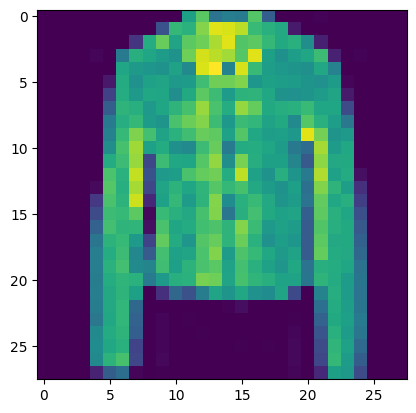

In [15]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()